### Multiplot for any rho experiment for a timeseries

In [2]:
import numpy as np
import xarray as xr
import pandas as pd
import scipy
import sys 
import warnings
warnings.filterwarnings('ignore')
import geopandas as gpd
from shapely.geometry import mapping
import cartopy.crs as ccrs
import cartopy.feature
import matplotlib.pyplot as plt

In [3]:
dataf ="/Volumes/New_5TB/ESA_F4R/2026_mergeds/" 
datao ="/Volumes/New_5TB/ESA_F4R/2026_rho/drc/" 
datap ="/Volumes/New_5TB/ESA_F4R/2026_plots/drc/" 
datam ="/Volumes/New_5TB/ESA_F4R/ERA5_monthly/" 

datas ="/Users/ellendyer/Library/Mobile Documents/com~apple~CloudDocs/1SHARED_WORK/Work/3_ESA_GRANT/MODEL/Shapefiles/"
shp_cod = gpd.read_file(datas+"geoBoundaries-COD-ADM0.shp")

S_NAME = "S_SE" # S_SE or S_LSE 
L_NAME = "L_HI" # L_M or L_HI

In [4]:
rho_xarr = xr.open_dataset(datao+L_NAME+"_"+S_NAME+"_drc_rot_rho_era5_precipfiltered.nc",engine='netcdf4')

In [ ]:
##Filtering out outliers for plotting 
#for r in np.arange(1,5):
#    print("*** Rotation is: ",r)
#    try:
#        print('Number of rhos over 1: ', rho_xarr['rho'][r-1,:,:,:].where(rho_xarr['rho'][r-1,:,:,:].values>1.0).count().values)
#        print('Number of negative rhos: ', rho_xarr['rho'][r-1,:,:,:].where(rho_xarr['rho'][r-1,:,:,:].values<0.0).count().values)
#        rho_xarr['rho'][r-1,:,:,:] = rho_xarr['rho'][r-1,:,:,:].where(rho_xarr['rho'][r-1,:,:,:].values<=1.0,np.nan)
#        rho_xarr['rho'][r-1,:,:,:] = rho_xarr['rho'][r-1,:,:,:].where(rho_xarr['rho'][r-1,:,:,:].values>0.0,np.nan)
#        print('Number of rhos over 1: ', rho_xarr['rho'][r-1,:,:,:].where(rho_xarr['rho'][r-1,:,:,:].values>1.0).count().values)
#        print('Number of negative rhos: ', rho_xarr['rho'][r-1,:,:,:].where(rho_xarr['rho'][r-1,:,:,:].values<0.0).count().values)
#        print('-------------------------')
#    except:
#        print('No outliers')
#        print(rho_xarr)

In [ ]:
#Monthly average plots - per rotation
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for M in range(1,13):
    for r in np.arange(1,5):
        rho_plot = rho_xarr['rho'][r-1,:,:,:] 
        month_rho = rho_plot.where(rho_plot['time.month']==M,drop=True).mean('time')
        fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
        ax.coastlines()
        ax.add_feature(cartopy.feature.BORDERS)
        ax.add_feature(cartopy.feature.RIVERS)
        #ax.add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
        cmap=plt.cm.viridis
        cmap.set_extremes(over='orange')
        collection = month_rho.plot.pcolormesh(vmin=0.0,vmax=0.8,
                                                    #levels=13,
                                                    ax=ax,extend='max',cmap=cmap,
                                                    cbar_kwargs={"location":"bottom"} )
        #ax.set_extent([band[B][2],band[B][3],band[B][0],band[B][1]])
        ax.set_extent([11, 32, -14, 6])
        ax.set_title(" $\\rho$"+" "+mon[M-1]+"\n DRC (rot "+str(r)+") \n"+L_NAME+" - "+S_NAME)
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
          linewidth=1, color='black', alpha=0.5, linestyle='dotted',zorder=100)
        gl.top_labels = False
        gl.right_labels = False
        plt.savefig(datap+L_NAME+"_"+S_NAME+"_rho_"+mon[M-1]+"_DRC_rot"+str(r)+".png")
        plt.show()
        plt.clf()
            
            
        

In [ ]:
#Monthly average plots - average rotation
mon = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
for M in range(1,13):
    rho_plot = rho_xarr['rho'].mean('rot') 
    month_rho = rho_plot.where(rho_plot['time.month']==M,drop=True).mean('time')
    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    cmap=plt.cm.viridis
    cmap.set_extremes(over='orange')
    collection = month_rho.plot.pcolormesh(vmin=0.0,vmax=0.8,
                                                #levels=13,
                                                ax=ax,extend='max',cmap=cmap,
                                                cbar_kwargs={"location":"bottom"} )
    #ax.set_extent([band[B][2],band[B][3],band[B][0],band[B][1]])
    ax.set_title(" $\\rho$"+" "+mon[M-1]+"\n DRC \n"+L_NAME+" - "+S_NAME)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
      linewidth=1, color='black', alpha=0.5, linestyle='dotted',zorder=100)
    gl.top_labels = False
    gl.right_labels = False
    plt.savefig(datap+L_NAME+"_"+S_NAME+"_rho_"+mon[M-1]+"_DRC_rotmean.png")
    plt.show()
    plt.clf()
            
            
        

In [ ]:
#Seasonal average plots - per rotation
seas={'MAM':[3,4,5],'SON':[9,10,11],'JJA':[6,7,8],'DJF':[1,2,12]}
for S in seas:
    for r in np.arange(1,5):
        rho_plot = rho_xarr['rho'][r-1,:,:,:] 
        seas_rho = rho_plot.where(rho_plot['time.month'].isin(seas[S]),drop=True).mean('time')
        #seas_rho = rho_plot.where(rho_plot['time.month']==M,drop=True).mean('time')
        fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
        ax.coastlines()
        ax.add_feature(cartopy.feature.BORDERS)
        ax.add_feature(cartopy.feature.RIVERS)
        ax.add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
        cmap=plt.cm.viridis
        cmap.set_extremes(over='orange')
        collection = seas_rho.plot.pcolormesh(vmin=0.0,vmax=0.8,
                                                        #levels=13,
                                                        ax=ax,extend='max',cmap=cmap,
                                                        cbar_kwargs={"location":"bottom"} )
        #ax.set_extent([band[B][2],band[B][3],band[B][0],band[B][1]])
        ax.set_title(" $\\rho$"+" "+S+"\n DRC (rot "+str(r)+") \n"+L_NAME+" - "+S_NAME)
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
              linewidth=1, color='black', alpha=0.5, linestyle='dotted',zorder=100)
        gl.top_labels = False
        gl.right_labels = False
        plt.savefig(datap+L_NAME+"_"+S_NAME+"_rho_"+S+"_DRC_rot"+str(r)+".png")
        plt.show()
        plt.clf()    
            
        

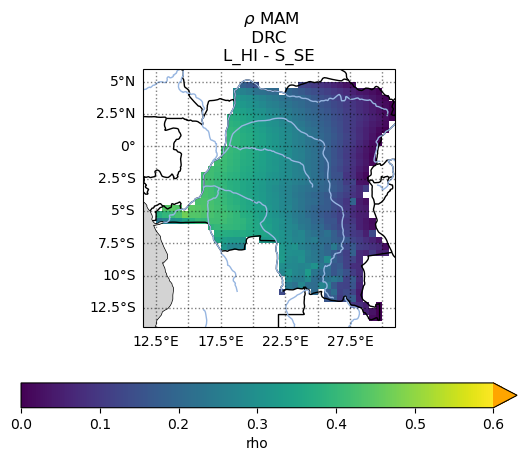

<Figure size 640x480 with 0 Axes>

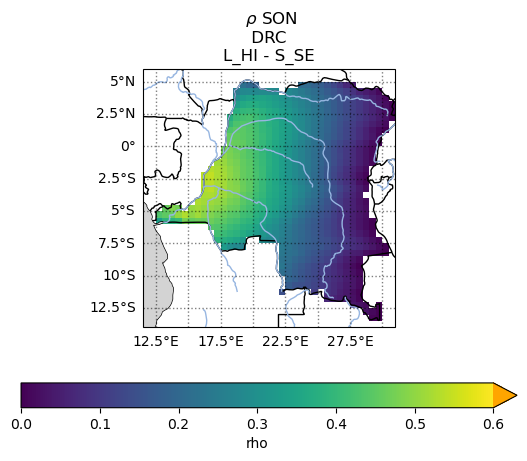

<Figure size 640x480 with 0 Axes>

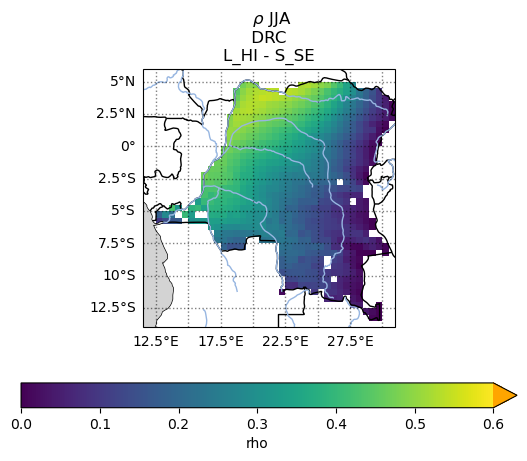

<Figure size 640x480 with 0 Axes>

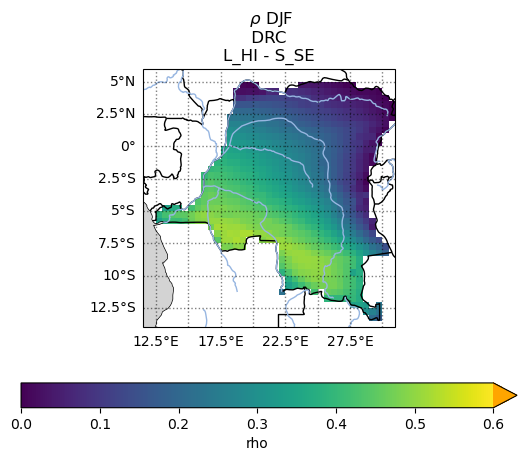

<Figure size 640x480 with 0 Axes>

In [5]:
#Seasonal average plots - average rotation
seas={'MAM':[3,4,5],'SON':[9,10,11],'JJA':[6,7,8],'DJF':[1,2,12]}
for S in seas:
    rho_plot = rho_xarr['rho'].mean('rot') 
    seas_rho = rho_plot.where(rho_plot['time.month'].isin(seas[S]),drop=True).mean('time')
    #seas_rho = rho_plot.where(rho_plot['time.month']==M,drop=True).mean('time')
    fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
    ax.coastlines()
    ax.add_feature(cartopy.feature.BORDERS)
    ax.add_feature(cartopy.feature.RIVERS)
    ax.add_feature(cartopy.feature.OCEAN,zorder=2,facecolor='lightgrey')
    cmap=plt.cm.viridis
    cmap.set_extremes(over='orange')
    collection = seas_rho.plot.pcolormesh(vmin=0.0,vmax=0.6,
                                                    #levels=13,
                                                    ax=ax,extend='max',cmap=cmap,
                                                    cbar_kwargs={"location":"bottom"} )
    #ax.set_extent([band[B][2],band[B][3],band[B][0],band[B][1]])
    ax.set_title(" $\\rho$"+" "+S+"\n DRC \n"+L_NAME+" - "+S_NAME)
    gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
          linewidth=1, color='black', alpha=0.5, linestyle='dotted',zorder=100)
    gl.top_labels = False
    gl.right_labels = False
    plt.savefig(datap+L_NAME+"_"+S_NAME+"_rho_"+S+"_DRC_rotmean.png")
    plt.show()
    plt.clf()
            
            
        

In [ ]:

#Individual year-month plots - per rotation
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=12
nrows=35
h = nrows
w = ncols
cmap=plt.cm.viridis
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')

for r in np.arange(1,5):

    # Define the figure and each axis for the 3 rows and 3 columns
    fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                            subplot_kw={'projection': ccrs.PlateCarree()},
                            gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                            layout="constrained",
                            figsize=(15,24))
    
    # axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
    axs=axs.flatten()
    
    RHO = rho_xarr['rho'].sel(rot=r)
    mtime = RHO['time']
    ap = 0.9*len(RHO.lon.values) / len(RHO.lat.values)
    
    #Loop over all of the models
    for i,T in enumerate(mtime):
    
            # Select the week 1 forecast from the specified model
            data=RHO.sel(time=T)
    
            # Contour plot
            cs=axs[i].pcolormesh(RHO['lon'].values,RHO['lat'].values,
                               data.values,
                               vmin=0.0,vmax=1.0,
                               #levels=13,
                               #extend='max',
                               cmap=cmap,
                               #aspect= ap,
                               rasterized=True,
                               transform = ccrs.PlateCarree())
    
            # Title each subplot with the name of the model
            axs[i].set_title(str(data["time.year"].values)+"-"+str("{:02d}".format(data["time.month"].values)),
                     fontsize=4)
    
            # Draw the coastines for each subplot
            axs[i].coastlines()
    
    # Adjust the location of the subplots on the page to make room for the colorbar
    fig.subplots_adjust(hspace=0,wspace=-0.5)
    #plt.tight_layout()
    
    # Add a colorbar axis at the bottom of the graph
    #cbar_ax = fig.add_axes([0.2, 0.001, 0.6, 0.02])

    # Draw the colorbar
    #cbar=fig.colorbar(cs,ax=cbar_ax,extend='both')#,shrink=0.5)
    cbar = fig.colorbar(cs, ax=axs, orientation='horizontal',
                        #location="bottom",
                        shrink=0.2,extend="both",fraction=0.2)
    
    # Add a big title at the top
    plt.suptitle("$\\rho$ DRC "+L_NAME+" "+S_NAME+" (rot:"+str(r)+")", fontsize=10,y=1.01,x=0.5)
    plt.savefig(datap+"DRC_"+L_NAME+"_"+S_NAME+"_rot_"+str(r)+".png",bbox_inches="tight",dpi=200)
    plt.show()
    plt.clf()
        

In [ ]:

#Individual year-month plots - average rotation
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
ncols=12
nrows=35
h = nrows
w = ncols
cmap=plt.cm.viridis
cmap.set_extremes(over='orange')
cmap.set_extremes(under='pink')

# Define the figure and each axis for the 3 rows and 3 columns
fig, axs = plt.subplots(nrows=nrows,ncols=ncols,
                        subplot_kw={'projection': ccrs.PlateCarree()},
                        gridspec_kw = {'wspace':-0.2, 'hspace':-0.5},
                        layout="constrained",
                        figsize=(15,24))

# axs is a 2 dimensional array of `GeoAxes`.  We will flatten it into a 1-D array
axs=axs.flatten()

RHO = rho_xarr['rho'].mean('rot')
mtime = RHO['time']
ap = 0.9*len(RHO.lon.values) / len(RHO.lat.values)

#Loop over all of the models
for i,T in enumerate(mtime):

        # Select the week 1 forecast from the specified model
        data=RHO.sel(time=T)

        # Contour plot
        cs=axs[i].pcolormesh(RHO['lon'].values,RHO['lat'].values,
                           data.values,
                           vmin=0.0,vmax=1.0,
                           #levels=13,
                           #extend='max',
                           cmap=cmap,
                           #aspect= ap,
                           rasterized=True,
                           transform = ccrs.PlateCarree())

        # Title each subplot with the name of the model
        axs[i].set_title(str(data["time.year"].values)+"-"+str("{:02d}".format(data["time.month"].values)),
                 fontsize=4)

        # Draw the coastines for each subplot
        axs[i].coastlines()

# Adjust the location of the subplots on the page to make room for the colorbar
fig.subplots_adjust(hspace=0,wspace=-0.5)
#plt.tight_layout()

# Add a colorbar axis at the bottom of the graph
#cbar_ax = fig.add_axes([0.2, 0.001, 0.6, 0.02])

# Draw the colorbar
#cbar=fig.colorbar(cs,ax=cbar_ax,extend='both')#,shrink=0.5)
cbar = fig.colorbar(cs, ax=axs, orientation='horizontal',
                    #location="bottom",
                    shrink=0.2,extend="both",fraction=0.2)

# Add a big title at the top
plt.suptitle("$\\rho$ DRC "+L_NAME+" "+S_NAME, fontsize=10,y=1.01,x=0.5)
plt.savefig(datap+"DRC_"+L_NAME+"_"+S_NAME+"_rotmean.png",bbox_inches="tight",dpi=200)
plt.show()
plt.clf()
        